Atividade Avaliativa 1 — Visão Computacional
Especialização em IA e AM / Data Science e Analytics

Disciplina: Aprendizagem de Máquina e Visão Computacional — Turma 2025

Professor: Dr. Sidnei Alves de Araújo

Data de Entrega: 20/05/2026

Alunos do grupo:

Willian dos Santos Souza - RA 626104990

Objetivo
Sistema de inspeção visual automática que detecta e conta parafusos e porcas em imagens RGB, verificando se cada conjunto possui exatamente 10 parafusos e 10 porcas.




#CONECTANDO E IMPORTANDO BIBLIOTECA

In [1]:
#Conectar e montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Mapear o caminho da pasta onde estão as imagens)
PATH = '/content/drive/MyDrive/imagens/'

In [3]:
#Importar bibliotecas necessárias
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import os

#CONFIGURAÇÕES DA ATIVIDADE E DIRETÓRIO

In [4]:
DEF_PARAFUSOS = 10
DEF_PORCAS = 10

In [5]:
img_avaliacao = 'img13.jpg'

In [6]:
#Caminho completo da imagem montado
caminho_imagem = PATH + img_avaliacao

In [7]:
print(f"Configurado para avaliar: {img_avaliacao}")

Configurado para avaliar: img13.jpg


In [8]:
#Leitura da imagem
imagem = cv.imread(caminho_imagem)

#Verificação de segurança para garantir que a imagem foi encontrada
if imagem is None:
    print(f"Erro: Não foi possível carregar a imagem em: {caminho_imagem}")
    print("Verifique se o nome do arquivo está correto e se a pasta existe no seu Drive.")
else:
    #Se encontrar, faz o processamento sem quebrar o código
    imagem_rgb = cv.cvtColor(imagem, cv.COLOR_BGR2RGB)
    imagem_cinza = cv.cvtColor(imagem, cv.COLOR_BGR2GRAY)
    imagem_blur = cv.GaussianBlur(imagem_cinza, (5,5), 0)
    print("Imagem carregada e processada com sucesso!")

Imagem carregada e processada com sucesso!


#PROCESSAMENTO DE IMAGEM E DETECÇÃO

In [9]:
imagem = cv.imread(caminho_imagem)

if imagem is None:
    print(f" ERRO CRÍTICO: Não foi possível carregar a imagem em: {caminho_imagem}")
    print("Verifique se o nome do arquivo e as pastas do caminho estão corretos.")
else:
    #Conversões de espaço de cor básicas
    imagem_rgb = cv.cvtColor(imagem, cv.COLOR_BGR2RGB)
    imagem_cinza = cv.cvtColor(imagem, cv.COLOR_BGR2GRAY)

    #Suavização Gaussiana para reduzir ruídos de alta frequência antes da binarização
    imagem_blur = cv.GaussianBlur(imagem_cinza, (5,5), 0)

In [10]:
#SEGMENTAÇÃO POR LIMIARIZAÇÃO (BINARIZAÇÃO)
_, imagem_binaria = cv.threshold(imagem_blur, 180, 255, cv.THRESH_BINARY)

In [11]:
#OPERAÇÃO MORFOLÓGICA (Abertura para eliminação de pequenos ruídos isolados)
elemento = np.ones((3,3), np.uint8)
imagem_binaria = cv.morphologyEx(imagem_binaria, cv.MORPH_OPEN, elemento)

In [12]:
#Extração dos contornos externos
contours, _ = cv.findContours(imagem_binaria, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

#Inicialização dos contadores
parafusos = 0
porcas = 0
imagem_saida = imagem_rgb.copy()

In [13]:
#LOOP DE ANÁLISE GEOMÉTRICA DOS OBJETOS DETECTADOS
for i, contorno in enumerate(contours):
    area = cv.contourArea(contorno)

    #Filtro de área mínima para ignorar pequenas impurezas residuais
    if area < 50:
        continue

    #Caixa delimitadora reta (Bounding Box para desenho na tela)
    x, y, w, h = cv.boundingRect(contorno)

    #Caixa rotacionada de área mínima para descobrir dimensões intrínsecas reais
    rect = cv.minAreaRect(contorno)
    (x_centro, y_centro), (largura_ret, altura_ret), angulo = rect

    #Cálculo do Aspect Ratio (Proporção de Aspecto) para classificar o formato do objeto
    if min(largura_ret, altura_ret) > 0:
        aspect_ratio = max(largura_ret, altura_ret) / min(largura_ret, altura_ret)
    else:
        aspect_ratio = 1.0

    #Classificação por Formato:
    #Se um lado for > 50% maior que o outro (Ratio > 1.5), classifica como Parafuso (Azul)
    if aspect_ratio > 1.5:
        parafusos += 1
        cv.rectangle(imagem_saida, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv.putText(imagem_saida, 'Parafuso', (x, y - 5), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    #Caso contrário (objeto simétrico/quadrado/redondo), classifica como Porca (Verde)
    else:
        porcas += 1
        cv.rectangle(imagem_saida, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv.putText(imagem_saida, 'Porca', (x, y - 5), cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

#Transferência de dados processados para variáveis de exibição
img_saida = imagem_saida
paraf_contado = parafusos
porca_contado = porcas

In [14]:
#COMPARAÇÃO COM OS ALVOS E MONITORAMENTO DE QUALIDADE
faltam_parafusos = DEF_PARAFUSOS - paraf_contado
faltam_porcas = DEF_PORCAS - porca_contado

print('\n========== RESULTADO DA AVALIAÇÃO ==========')
print(f'Parafusos contados : {paraf_contado} / Esperados: {DEF_PARAFUSOS}')
print(f'Porcas contadas    : {porca_contado} / Esperadas: {DEF_PORCAS}')
print('--------------------------------------------')

#Validação do lote
if faltam_parafusos == 0 and faltam_porcas == 0:
    resultado_imp = f'CONJUNTO APROVADO: Contém {DEF_PARAFUSOS} parafusos e {DEF_PORCAS} porcas.'
    print(" STATUS: LOTE APROVADO")
else:
    print(" STATUS: LOTE REPROVADO")
    #Estrutura lógica de strings para exibição de divergências no relatório visual
    if faltam_parafusos > 0:
        resultado_imp = f'CONJUNTO REPROVADO: Faltam {faltam_parafusos} parafuso(s).'
    elif faltam_parafusos < 0:
        resultado_imp = f'CONJUNTO REPROVADO: {abs(faltam_parafusos)} parafuso(s) em excesso.'

    if faltam_porcas > 0:
        resultado_imp = f'CONJUNTO REPROVADO: Faltam {faltam_porcas} porca(s).'
    elif faltam_porcas < 0:
        resultado_imp = f'CONJUNTO REPROVADO: {abs(faltam_porcas)} porca(s) em excesso.'


========== RESULTADO DA AVALIAÇÃO ==========
Parafusos contados : 0 / Esperados: 10
Porcas contadas    : 10 / Esperadas: 10
--------------------------------------------
 STATUS: LOTE REPROVADO


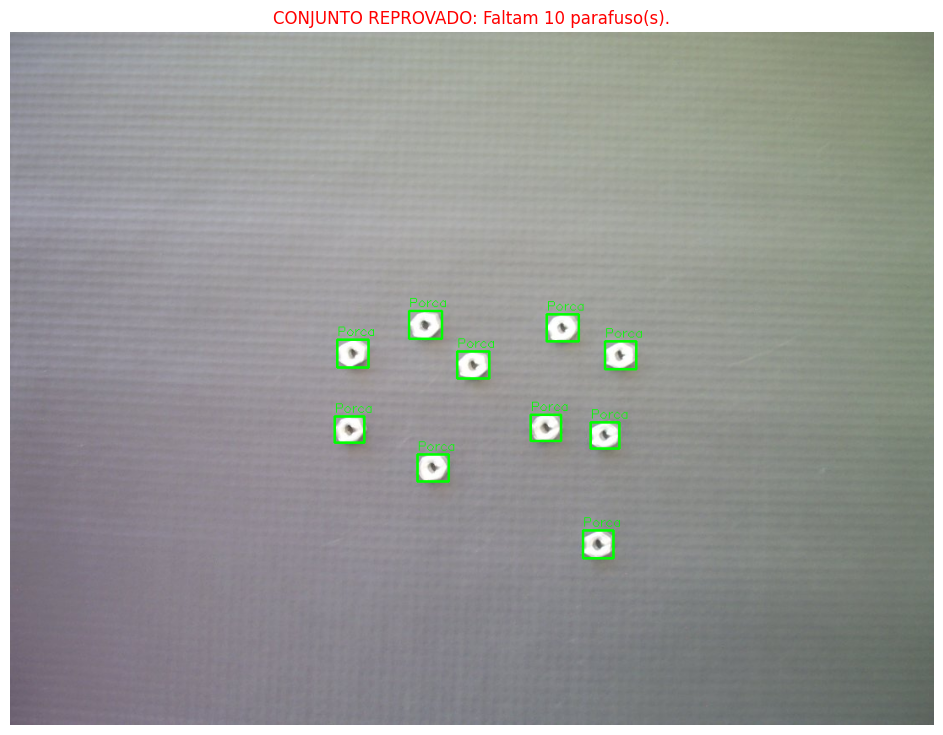

In [15]:
#EXIBIÇÃO DO RESULTADO GRAFICAMENTE
plt.figure(figsize=(12, 9))
plt.imshow(img_saida)
plt.title(resultado_imp, fontsize=12, color='green' if (faltam_parafusos == 0 and faltam_porcas == 0) else 'red')
plt.axis('off')
plt.show()